In [3]:
from preprocessing import get_data, get_encoded_data, split_data

features, target = get_data()
encoded_features, target = get_encoded_data(features, target)
X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(encoded_features, target)

Validation 성능 - Accuracy: 0.78, F1 Score: 0.51


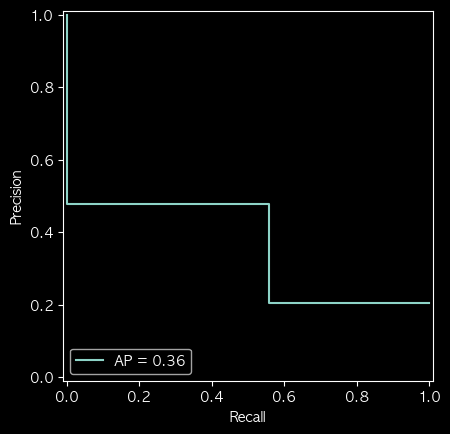

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_recall_curve, PrecisionRecallDisplay, average_precision_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
valid_pred = model.predict(X_valid)
valid_pred_proba = model.predict_proba(X_valid)[:, 1]

accuracy = accuracy_score(y_valid, valid_pred)
f1 = f1_score(y_valid, valid_pred)
ap_score = average_precision_score(y_valid, valid_pred_proba)

precision, recall, _ = precision_recall_curve(y_valid, valid_pred_proba)
display = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap_score)
display.plot()
print(f"Validation 성능 - Accuracy: {accuracy:.2f}, F1 Score: {f1:.2f}")